In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline

In [4]:
output_file = "../data/02_processed/CIC-IDS2017_processed.csv"
df1=pd.read_csv("../data/01_raw/CIC-IDS2017/CSV/Monday-WorkingHours.pcap_ISCX.csv")
df2=pd.read_csv("../data/01_raw/CIC-IDS2017/CSV/Tuesday-WorkingHours.pcap_ISCX.csv")
df3=pd.read_csv("../data/01_raw/CIC-IDS2017/CSV/Wednesday-workingHours.pcap_ISCX.csv")
df4=pd.read_csv("../data/01_raw/CIC-IDS2017/CSV/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv")
df5=pd.read_csv("../data/01_raw/CIC-IDS2017/CSV/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv", encoding="cp1252", low_memory=False)
df6=pd.read_csv("../data/01_raw/CIC-IDS2017/CSV/Friday-WorkingHours-Morning.pcap_ISCX.csv")
df7=pd.read_csv("../data/01_raw/CIC-IDS2017/CSV/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv")
df8=pd.read_csv("../data/01_raw/CIC-IDS2017/CSV/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv", low_memory=False)

In [5]:
df=pd.concat([df1, df2, df3, df4, df5, df6, df7, df8], ignore_index=True)
df.shape

(3119345, 86)

In [6]:
df.columns

Index(['Flow ID', ' Source IP', ' Source Port', ' Destination IP',
       ' Destination Port', ' Protocol', ' Timestamp', ' Flow Duration',
       ' Total Fwd Packets', ' Total Backward Packets',
       'Total Length of Fwd Packets', ' Total Length of Bwd Packets',
       ' Fwd Packet Length Max', ' Fwd Packet Length Min',
       ' Fwd Packet Length Mean', ' Fwd Packet Length Std',
       'Bwd Packet Length Max', ' Bwd Packet Length Min',
       ' Bwd Packet Length Mean', ' Bwd Packet Length Std', 'Flow Bytes/s',
       ' Flow Packets/s', ' Flow IAT Mean', ' Flow IAT Std', ' Flow IAT Max',
       ' Flow IAT Min', 'Fwd IAT Total', ' Fwd IAT Mean', ' Fwd IAT Std',
       ' Fwd IAT Max', ' Fwd IAT Min', 'Bwd IAT Total', ' Bwd IAT Mean',
       ' Bwd IAT Std', ' Bwd IAT Max', ' Bwd IAT Min', 'Fwd PSH Flags',
       ' Bwd PSH Flags', ' Fwd URG Flags', ' Bwd URG Flags',
       ' Fwd Header Length', ' Bwd Header Length', 'Fwd Packets/s',
       ' Bwd Packets/s', ' Min Packet Length', ' Max Pa

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3119345 entries, 0 to 3119344
Data columns (total 86 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   Flow ID                       object 
 1    Source IP                    object 
 2    Source Port                  float64
 3    Destination IP               object 
 4    Destination Port             float64
 5    Protocol                     float64
 6    Timestamp                    object 
 7    Flow Duration                float64
 8    Total Fwd Packets            float64
 9    Total Backward Packets       float64
 10  Total Length of Fwd Packets   float64
 11   Total Length of Bwd Packets  float64
 12   Fwd Packet Length Max        float64
 13   Fwd Packet Length Min        float64
 14   Fwd Packet Length Mean       float64
 15   Fwd Packet Length Std        float64
 16  Bwd Packet Length Max         float64
 17   Bwd Packet Length Min        float64
 18   Bwd Packet Length Mea

In [8]:
df.columns=df.columns.str.strip()
df.drop(columns=["Fwd Header Length.1", "External IP"], inplace=True)
df.shape

(3119345, 84)

In [9]:
df[pd.isnull(df["Flow ID"])]

,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,Total Backward Packets,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
2127498,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2127499,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2127500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2127501,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2127502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2416095,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2416096,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2416097,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2416098,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.shape

(2827876, 84)

In [11]:
df.drop_duplicates(inplace=True)
df.shape

(2827677, 84)

In [12]:
df.Label.unique()

array(['BENIGN', 'FTP-Patator', 'SSH-Patator', 'DoS slowloris',
       'DoS Slowhttptest', 'DoS Hulk', 'DoS GoldenEye', 'Heartbleed',
       'Infiltration', 'Web Attack – Brute Force', 'Web Attack – XSS',
       'Web Attack – Sql Injection', 'Bot', 'PortScan', 'DDoS'],
      dtype=object)

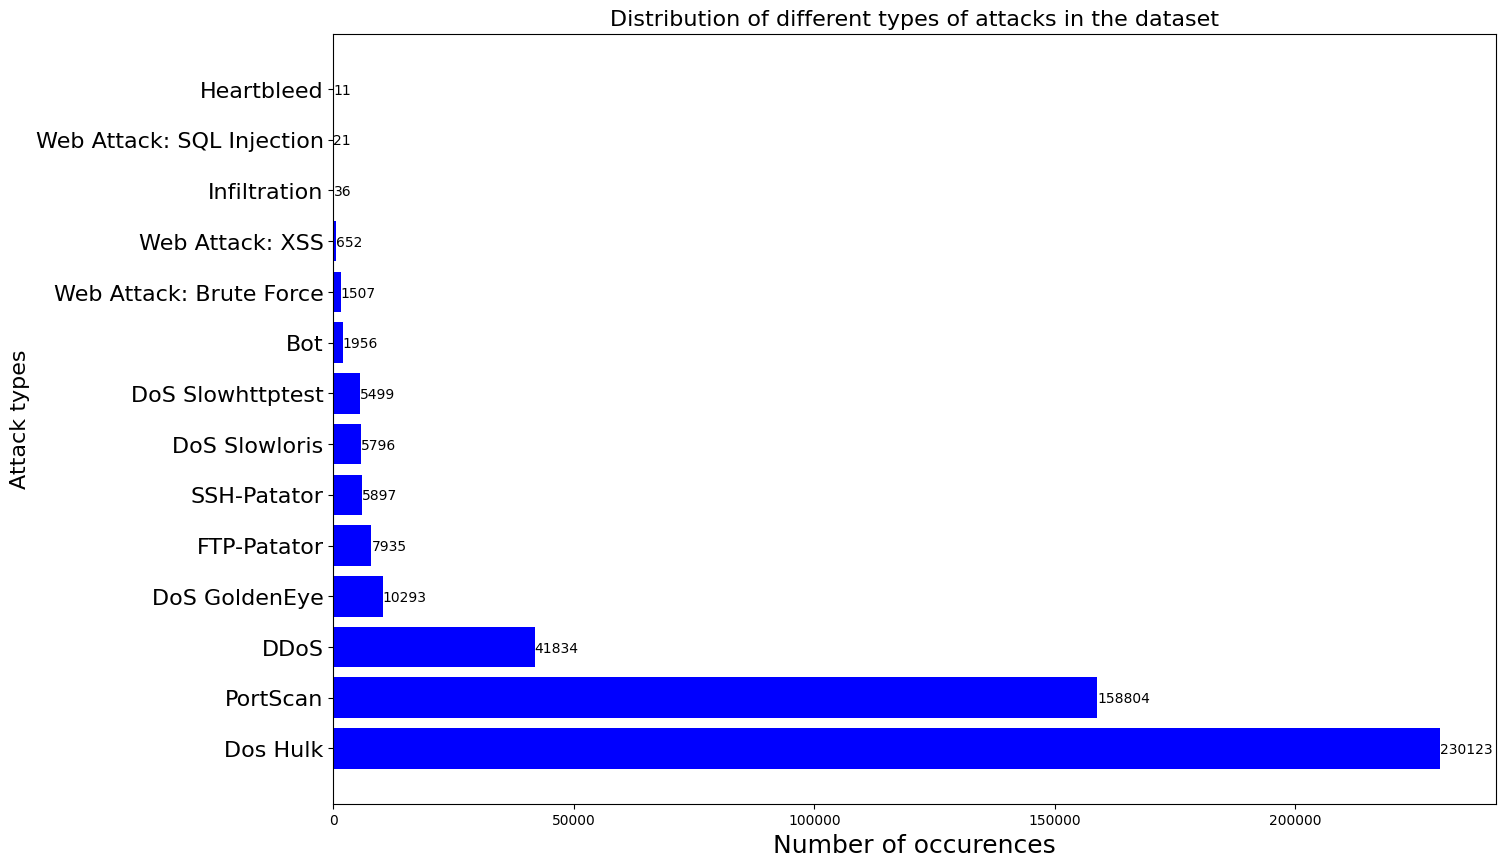

In [13]:
plt.figure(figsize=(15, 10))

attack=(
    "Dos Hulk",
    "PortScan",
    "DDoS",
    "DoS GoldenEye",
    "FTP-Patator",
    "SSH-Patator",
    "DoS Slowloris",
    "DoS Slowhttptest",
    "Bot",
    "Web Attack: Brute Force",
    "Web Attack: XSS",
    "Infiltration",
    "Web Attack: SQL Injection",
    "Heartbleed"
)
y_pos=np.arange(len(attack))
amount=df["Label"].value_counts()[1:]
plt.barh(y_pos, amount, align="center", color="blue")
plt.yticks(y_pos, attack, fontsize=16)
plt.title("Distribution of different types of attacks in the dataset", fontsize=16)
plt.xlabel("Number of occurences", fontsize=18)
plt.ylabel("Attack types", fontsize=16)
for i, v in enumerate(amount):
    plt.text(v+3, i-0.1, str(v))

plt.show()

In [14]:
df.shape

(2827677, 84)

In [15]:
Path(output_file).parent.mkdir(parents=True, exist_ok=True)
df.to_csv(output_file, index=False)

In [16]:
df_p=pd.read_csv(output_file)

In [17]:
df_p.Label.value_counts()

Label
BENIGN                        2357313
DoS Hulk                       230123
PortScan                       158804
DDoS                            41834
DoS GoldenEye                   10293
FTP-Patator                      7935
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1956
Web Attack – Brute Force         1507
Web Attack – XSS                  652
Infiltration                       36
Web Attack – Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64